In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/home/spandan/Desktop/project/Netflix-analysis/data/netflix_titles.csv")


In [3]:
df["country"] = df["country"].fillna("Unknown")
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")


In [4]:
df = df.dropna(subset=["date_added"])

In [5]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())

In [6]:
df["duration_num"] = df["duration"].str.extract(r'(\d+)').astype(float)

In [7]:
df["is_movie"] = df["duration"].str.contains("min")

In [8]:
df["duration_minutes"] = df["duration_num"].where(df["is_movie"])
df["seasons"] = df["duration_num"].where(~df["is_movie"])

In [9]:
df["year_added"] = df["date_added"].dt.year

year_counts = df["year_added"].value_counts().sort_index()

In [10]:
df["genres"] = df["listed_in"].str.split(", ")

In [11]:
type_counts = df["type"].value_counts()

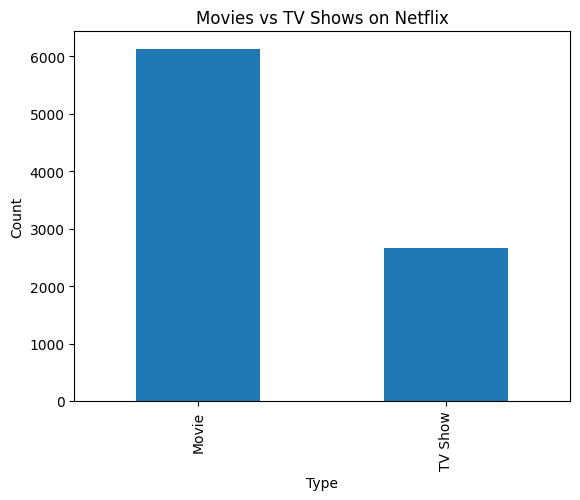

Insight: Netflix has more Movie than other type.



In [12]:
plt.figure()
type_counts.plot(kind="bar")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

print("Insight: Netflix has more", type_counts.idxmax(), "than other type.\n")

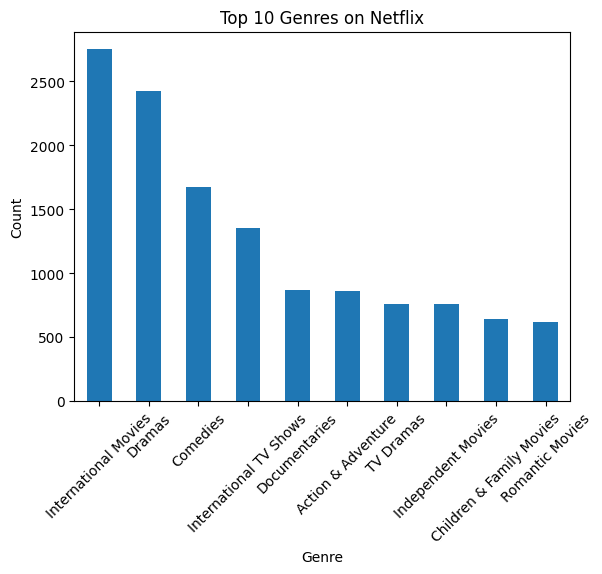

Insight: Most popular genre: International Movies 



In [13]:
all_genres = df["genres"].explode()
genre_counts = all_genres.value_counts().head(10)

plt.figure()
genre_counts.plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print("Insight: Most popular genre:", genre_counts.idxmax(), "\n")

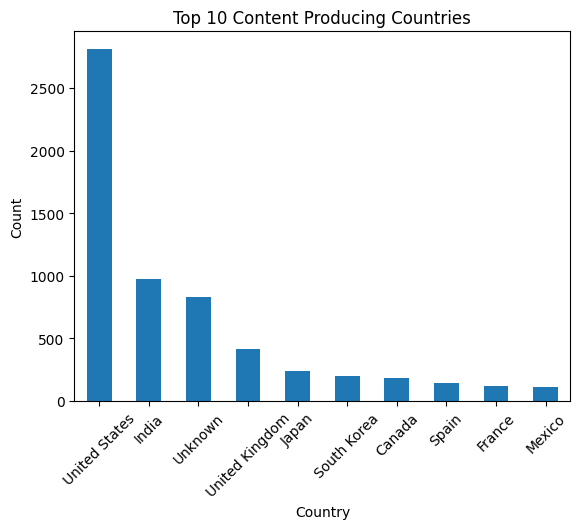

Insight: Most content comes from: United States 



In [14]:
country_counts = df["country"].value_counts().head(10)

plt.figure()
country_counts.plot(kind="bar")
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print("Insight: Most content comes from:", country_counts.idxmax(), "\n")

In [15]:
avg_duration = df["duration_minutes"].mean()
print("Average movie duration:", round(avg_duration, 2), "minutes\n")

Average movie duration: 99.58 minutes



In [16]:
print("===== FINAL INSIGHTS =====")
print("1. Most content type:", type_counts.idxmax())
print("2. Peak year:", year_counts.idxmax())
print("3. Top genre:", genre_counts.idxmax())
print("4. Top country:", country_counts.idxmax())
print("5. Avg movie duration:", round(avg_duration, 2), "minutes")

===== FINAL INSIGHTS =====
1. Most content type: Movie
2. Peak year: 2019
3. Top genre: International Movies
4. Top country: United States
5. Avg movie duration: 99.58 minutes
